In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import re
import string
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"PyTorch version: {torch.__version__}")


Libraries imported successfully
TensorFlow version: 2.20.0
PyTorch version: 2.10.0+cu128


In [3]:
print("Loading IMDB dataset...")
dataset = load_dataset("imdb")

train_data = dataset['train']
test_data = dataset['test']

print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")
print(f"Sample review: {train_data[0]['text'][:200]}...")
print(f"Label: {train_data[0]['label']}")


Loading IMDB dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 25000
Test size: 25000
Sample review: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev...
Label: 0


In [4]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'http\S+|www.\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("Preprocessing texts...")
train_texts = [preprocess_text(item['text']) for item in train_data]
train_labels = [item['label'] for item in train_data]

test_texts = [preprocess_text(item['text']) for item in test_data]
test_labels = [item['label'] for item in test_data]

print("Sample preprocessed text:")
print(train_texts[0][:200])


Preprocessing texts...
Sample preprocessed text:
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by us customs if it ever tried 


In [5]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts, train_labels, test_size=0.2, random_state=42, stratify=train_labels
)

print(f"Train size: {len(train_texts)}")
print(f"Validation size: {len(val_texts)}")
print(f"Test size: {len(test_texts)}")


Train size: 20000
Validation size: 5000
Test size: 25000


In [6]:
MAX_WORDS = 10000
MAX_LEN = 200

tokenizer_rnn = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer_rnn.fit_on_texts(train_texts)

X_train = tokenizer_rnn.texts_to_sequences(train_texts)
X_val = tokenizer_rnn.texts_to_sequences(val_texts)
X_test = tokenizer_rnn.texts_to_sequences(test_texts)

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_val = pad_sequences(X_val, maxlen=MAX_LEN, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=MAX_LEN, padding='post', truncating='post')

y_train = np.array(train_labels)
y_val = np.array(val_labels)
y_test = np.array(test_labels)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (20000, 200)
X_val shape: (5000, 200)
X_test shape: (25000, 200)


In [7]:
print("Building Simple RNN model...")

model_rnn = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()


Building Simple RNN model...


I0000 00:00:1783008218.314130      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783008218.318259      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

print("Training Simple RNN model...")
history_rnn = model_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Training Simple RNN model...
Epoch 1/10
  7/157 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5140 - loss: 0.7098

I0000 00:00:1783008222.529733      93 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.4976 - loss: 0.7004 - val_accuracy: 0.5082 - val_loss: 0.6933 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5949 - loss: 0.6605 - val_accuracy: 0.5136 - val_loss: 0.7086 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6769 - loss: 0.5585 - val_accuracy: 0.5108 - val_loss: 0.7728 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7480 - loss: 0.4252 - val_accuracy: 0.5202 - val_loss: 0.8193 - learning_rate: 5.0000e-04


In [9]:
loss_rnn, acc_rnn = model_rnn.evaluate(X_test, y_test, verbose=0)
print(f"\nSimple RNN Test Accuracy: {acc_rnn:.4f}")
print(f"Simple RNN Test Loss: {loss_rnn:.4f}")

y_pred_rnn = (model_rnn.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("\nClassification Report for Simple RNN:")
print(classification_report(y_test, y_pred_rnn, target_names=['Negative', 'Positive']))



Simple RNN Test Accuracy: 0.5083
Simple RNN Test Loss: 0.6932

Classification Report for Simple RNN:
              precision    recall  f1-score   support

    Negative       0.52      0.22      0.31     12500
    Positive       0.51      0.79      0.62     12500

    accuracy                           0.51     25000
   macro avg       0.51      0.51      0.46     25000
weighted avg       0.51      0.51      0.46     25000



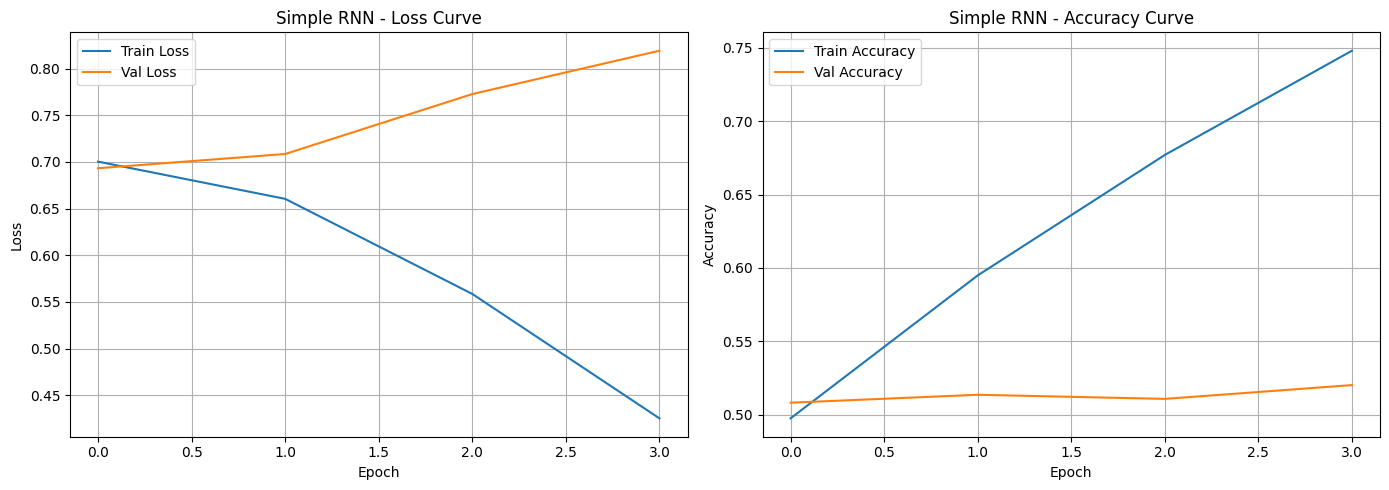

In [10]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Val Loss')
plt.title('Simple RNN - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Val Accuracy')
plt.title('Simple RNN - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('rnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
print("Building LSTM model...")

model_lstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=128, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()


Building LSTM model...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
print("Training LSTM model...")
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Training LSTM model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.5189 - loss: 0.6917 - val_accuracy: 0.5176 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5477 - loss: 0.7275 - val_accuracy: 0.5132 - val_loss: 0.6900 - learning_rate: 0.0010
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5102 - loss: 0.6996 - val_accuracy: 0.5306 - val_loss: 0.6867 - learning_rate: 0.0010
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5501 - loss: 0.6767 - val_accuracy: 0.6012 - val_loss: 0.6459 - learning_rate: 0.0010
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6117 - loss: 0.6531 - val_accuracy: 0.6644 - val_loss: 0.6286 - learning_rate: 0.0010
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7118 - loss: 0.5800 - val_accuracy: 0.6876 - val_loss: 0.6095 - learning_rate: 0.0010
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accu

In [13]:
loss_lstm, acc_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f"\nLSTM Test Accuracy: {acc_lstm:.4f}")
print(f"LSTM Test Loss: {loss_lstm:.4f}")

y_pred_lstm = (model_lstm.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("\nClassification Report for LSTM:")
print(classification_report(y_test, y_pred_lstm, target_names=['Negative', 'Positive']))



LSTM Test Accuracy: 0.6713
LSTM Test Loss: 0.6348

Classification Report for LSTM:
              precision    recall  f1-score   support

    Negative       0.68      0.65      0.66     12500
    Positive       0.66      0.70      0.68     12500

    accuracy                           0.67     25000
   macro avg       0.67      0.67      0.67     25000
weighted avg       0.67      0.67      0.67     25000



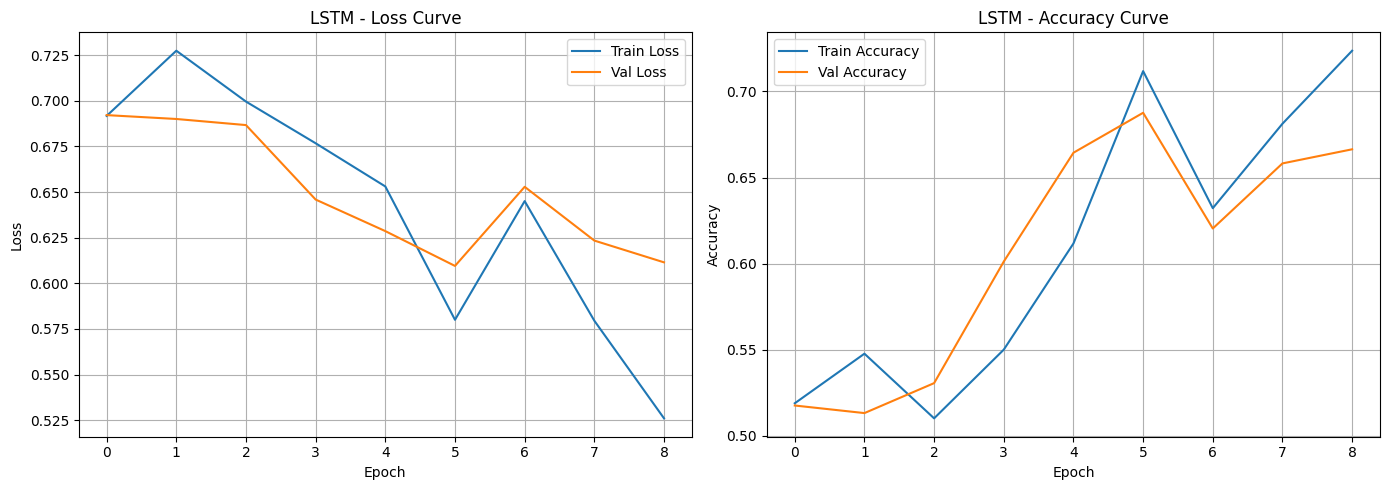

In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('LSTM - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
print("\n" + "="*80)
print("LSTM vs Simple RNN - Why LSTM performs better:")
print("="*80)
print("""
1. Vanishing Gradient Problem:
   - Simple RNN suffers from vanishing gradients in long sequences
   - Gradients become very small as they backpropagate through time
   - This makes it hard to learn long-term dependencies

2. LSTM Solution:
   - Uses gating mechanisms (forget gate, input gate, output gate)
   - Cell state acts as a highway for information flow
   - Gates allow gradient to flow unchanged through many timesteps
   - Can selectively remember or forget information

3. Performance Impact:
   - LSTM can capture long-range dependencies in movie reviews
   - Better at understanding context across entire review
   - More stable training due to better gradient flow
""")
print("="*80)



LSTM vs Simple RNN - Why LSTM performs better:

1. Vanishing Gradient Problem:
   - Simple RNN suffers from vanishing gradients in long sequences
   - Gradients become very small as they backpropagate through time
   - This makes it hard to learn long-term dependencies

2. LSTM Solution:
   - Uses gating mechanisms (forget gate, input gate, output gate)
   - Cell state acts as a highway for information flow
   - Gates allow gradient to flow unchanged through many timesteps
   - Can selectively remember or forget information

3. Performance Impact:
   - LSTM can capture long-range dependencies in movie reviews
   - Better at understanding context across entire review
   - More stable training due to better gradient flow



In [16]:
print("Preparing data for BERT...")

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = bert_tokenizer(
    train_texts, 
    truncation=True, 
    padding=True, 
    max_length=256,
    return_tensors='pt'
)
val_encodings = bert_tokenizer(
    val_texts, 
    truncation=True, 
    padding=True, 
    max_length=256,
    return_tensors='pt'
)
test_encodings = bert_tokenizer(
    test_texts, 
    truncation=True, 
    padding=True, 
    max_length=256,
    return_tensors='pt'
)

print("BERT tokenization complete")


Preparing data for BERT...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

BERT tokenization complete


In [17]:
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDBDataset(train_encodings, train_labels)
val_dataset = IMDBDataset(val_encodings, val_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

print(f"BERT datasets created - Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


BERT datasets created - Train: 20000, Val: 5000, Test: 25000


In [18]:
print("Loading BERT model...")
model_bert = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_bert.to(device)
print(f"Using device: {device}")


Loading BERT model...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


In [19]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average='binary')
    return {'accuracy': acc, 'f1': f1}

trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Fine-tuning BERT model...")
trainer.train()


`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Fine-tuning BERT model...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.549671,0.560440,0.896200,0.889315
2,0.310699,0.394685,0.925000,0.924623
3,0.161020,0.646065,0.923800,0.923386


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1875, training_loss=0.40784058634440107, metrics={'train_runtime': 1599.3561, 'train_samples_per_second': 37.515, 'train_steps_per_second': 1.172, 'total_flos': 7893331660800000.0, 'train_loss': 0.40784058634440107, 'epoch': 3.0})

In [20]:
print("Evaluating BERT on test set...")
test_results = trainer.evaluate(test_dataset)

print(f"\nBERT Test Results:")
print(f"Accuracy: {test_results['eval_accuracy']:.4f}")
print(f"F1 Score: {test_results['eval_f1']:.4f}")
print(f"Loss: {test_results['eval_loss']:.4f}")


Evaluating BERT on test set...



BERT Test Results:
Accuracy: 0.9207
F1 Score: 0.9202
Loss: 0.4102



Classification Report for BERT:
              precision    recall  f1-score   support

    Negative       0.92      0.93      0.92     12500
    Positive       0.93      0.91      0.92     12500

    accuracy                           0.92     25000
   macro avg       0.92      0.92      0.92     25000
weighted avg       0.92      0.92      0.92     25000



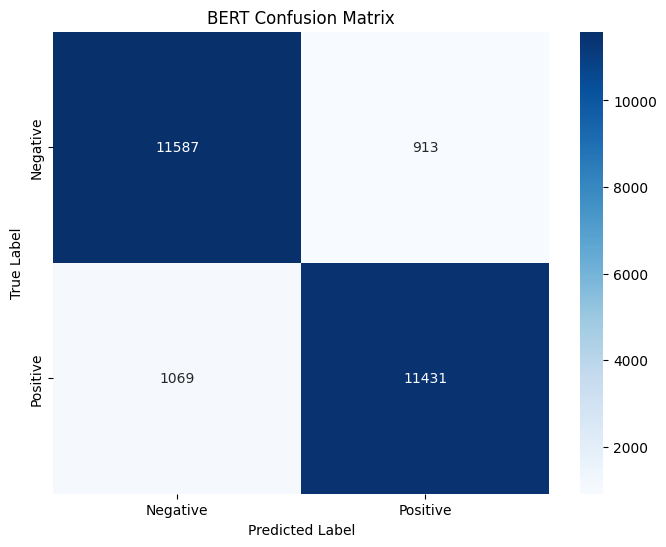

In [21]:
predictions = trainer.predict(test_dataset)
y_pred_bert = predictions.predictions.argmax(-1)

print("\nClassification Report for BERT:")
print(classification_report(y_test, y_pred_bert, target_names=['Negative', 'Positive']))

cm_bert = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('BERT Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()



FINAL COMPARISON OF ALL MODELS
     Model  Test Accuracy  F1 Score
Simple RNN        0.50828  0.617743
      LSTM        0.67128  0.679335
      BERT        0.92072  0.920222


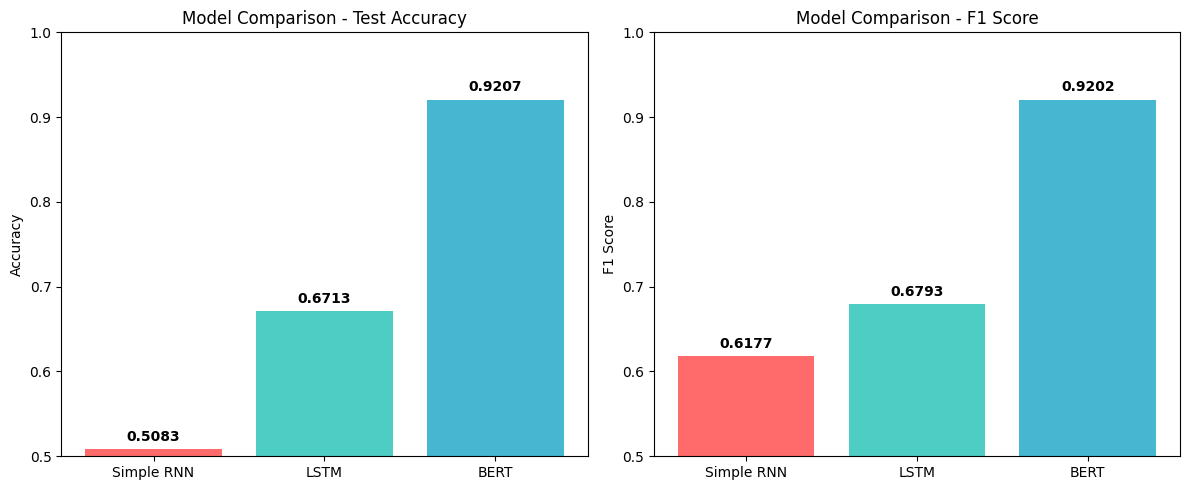

In [22]:
results_df = pd.DataFrame({
    'Model': ['Simple RNN', 'LSTM', 'BERT'],
    'Test Accuracy': [acc_rnn, acc_lstm, test_results['eval_accuracy']],
    'F1 Score': [
        f1_score(y_test, y_pred_rnn),
        f1_score(y_test, y_pred_lstm),
        test_results['eval_f1']
    ]
})

print("\n" + "="*80)
print("FINAL COMPARISON OF ALL MODELS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(results_df['Model'], results_df['Test Accuracy'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Model Comparison - Test Accuracy')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1.0])
for i, v in enumerate(results_df['Test Accuracy']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.bar(results_df['Model'], results_df['F1 Score'], color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title('Model Comparison - F1 Score')
plt.ylabel('F1 Score')
plt.ylim([0.5, 1.0])
for i, v in enumerate(results_df['F1 Score']):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
print("\n" + "="*80)
print("KEY INSIGHTS AND CONCLUSIONS")
print("="*80)
print("""
1. Model Performance Ranking:
   BERT > LSTM > Simple RNN
   
2. Why BERT Outperforms:
   - Pre-trained on massive text corpus
   - Bidirectional context understanding
   - Attention mechanism captures relationships better
   - Transfer learning advantage
   
3. LSTM vs Simple RNN:
   - LSTM solves vanishing gradient problem
   - Better long-term dependency modeling
   - Gating mechanism provides selective memory
   
4. Practical Considerations:
   - BERT: Highest accuracy but computationally expensive
   - LSTM: Good balance of performance and efficiency
   - Simple RNN: Fast but limited for complex sequences
   
5. Real-world Recommendation:
   - Use BERT for production if resources allow
   - Use LSTM for resource-constrained environments
   - Simple RNN only for very simple tasks or baselines
""")
print("="*80)

print("\nAll models trained and evaluated successfully!")
print("Training curves and comparison plots saved.")



KEY INSIGHTS AND CONCLUSIONS

1. Model Performance Ranking:
   BERT > LSTM > Simple RNN
   
2. Why BERT Outperforms:
   - Pre-trained on massive text corpus
   - Bidirectional context understanding
   - Attention mechanism captures relationships better
   - Transfer learning advantage
   
3. LSTM vs Simple RNN:
   - LSTM solves vanishing gradient problem
   - Better long-term dependency modeling
   - Gating mechanism provides selective memory
   
4. Practical Considerations:
   - BERT: Highest accuracy but computationally expensive
   - LSTM: Good balance of performance and efficiency
   - Simple RNN: Fast but limited for complex sequences
   
5. Real-world Recommendation:
   - Use BERT for production if resources allow
   - Use LSTM for resource-constrained environments
   - Simple RNN only for very simple tasks or baselines


All models trained and evaluated successfully!
Training curves and comparison plots saved.
